In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Required to import shared functions
import sys
sys.path.append('../src/')

In [2]:
#Importing shared .py file containing shared functions
import utils
import importlib
importlib.reload(utils)

<module 'utils' from '/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Notebooks/../src/utils.py'>

In [3]:
#Importing Cosmological Pars and original power spectrum functions

from utils import h, Om_m, Om_b, Om_lambda, rho_c, delta_c, sigma8_obs, n, z_range, f_b, H0, H, W, T, D, P, Pi, sigma_R, sigma_M, A, rho_0

## Original Power Spectrum

In [25]:
# Evaluate and print the normalization factor
R8 = 8/h      # units of Mpc

A = sigma8_obs/sigma_R(R8,0)
print(sigma_R(R8,0,1000))
print(f"Normalization factor A for sigma_8 = {sigma8_obs} is A = {A}")

0.00022314453983950192
Normalization factor A for sigma_8 = 0.811 is A = 3634.415615023862


In [5]:
from scipy.integrate import quad

In [6]:
k_range = np.linspace(1, 999)
P_old_test_vals = np.zeros((len(z_range), len(k_range)))

for i in range(len(z_range)):
    for j in range(len(k_range)):
        P_old_test_vals[i][j] = A * P(k_range[j], z_range[i], cutoff = np.inf)

## New Power Spectrum

In [7]:
def P_new(k, z, A_G, k_mean, k_var, cutoff=np.inf): #Power spectrum evolution
    if k<=cutoff:    
        return Pi_new(k, A_G, k_mean, k_var)*(T(k)*D(z))**2
    else:
        return 0

# Primordial power spectrum (un-normalised)
def Pi_new(k, A_G, k_mean, k_var):
    return k ** n * (1 + A_G * (1 / (k_var * np.sqrt(2 * np.pi))) * np.e ** (-1 / 2 * ((k - k_mean) / k_var) ** 2))

In [204]:
def P_new(k, z, A_G, k_mean, k_var, cutoff=np.inf):

    P = Pi_new(k, A_G, k_mean, k_var) * (T(k)*D(z))**2

    return np.where(k <= cutoff, P, 0.0)

In [205]:
# Variance of smoothed density field (wrt radius, R)
def sigma_R_new(R, A_G, k_mean, k_var, z=0, cutoff=np.inf):    
    # Integrand for the variance calculation
    def integral(k):
        return P_new(k, z, A_G, k_mean, k_var, cutoff) * k**2 * W(k,R)**2 / (2 * np.pi**2)
    
    sigma2, _ = quad(integral, 0, np.inf, limit=100000, epsabs=1e-5, epsrel=1e-5)
    return np.sqrt(sigma2)


# Variance of smoothed density field (wrt mass of region, M)
def sigma_M_new(M, A_G, k_mean, k_var, z=0, cutoff=np.inf):
    # Compute R corresponding to the mass M
    R = (3 * M / (4 * np.pi * rho_0))**(1/3)
    
    return sigma_R_new(R,A_G, k_mean, k_var, z, cutoff)

In [206]:
def sigma_R_new(R, A_G, k_mean, k_var, z=0, cutoff=np.inf):

    logk = np.linspace(-4, 5, 20000)
    k = 10**logk

    integrand = (
        np.log(10)
        * P_new(k, z, A_G, k_mean, k_var, cutoff)
        * k**3
        * W(k, R)**2
        / (2*np.pi**2)
    )

    sigma2 = simpson(integrand, x=logk)

    return np.sqrt(sigma2)

# Variance of smoothed density field (wrt mass of region, M)
def sigma_M_new(M, A_G, k_mean, k_var, z=0, cutoff=np.inf):
    # Compute R corresponding to the mass M
    R = (3 * M / (4 * np.pi * rho_0))**(1/3)
    
    return sigma_R_new(R,A_G, k_mean, k_var, z, cutoff)

In [241]:
#Gaussian Parameters

A_G_val = 10**4
k_mean_val = np.array([30, 100, 300])
k_var_val = 50

In [242]:
from scipy.integrate import simpson

In [243]:
# Evaluate and print the normalization factor

A_new = sigma8_obs/sigma_R_new(R8, A_G_val, k_mean_val[2], k_var_val, 0)
print(sigma_R_new(R8, A_G_val, k_mean_val[2], k_var_val))
print(f"Normalization factor A for sigma_8 = {sigma8_obs} is A = {A_new}")

0.0002231320419130435
Normalization factor A for sigma_8 = 0.811 is A = 3634.6191835417962


In [244]:
P_test_vals = np.zeros((len(k_mean_val), len(z_range), len(k_range)))

for p in range(len(k_mean_val)):
    for i in range(len(z_range)):
        for j in range(len(k_range)):
            P_test_vals[p, i, j] = A_new * P_new(k_range[j], z_range[i], A_G_val, k_mean_val[p], k_var_val, cutoff=np.inf)

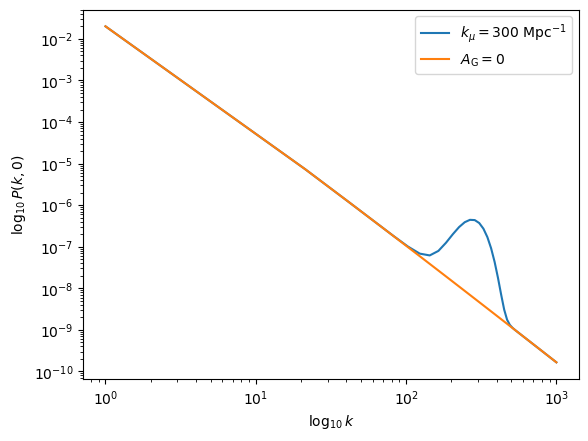

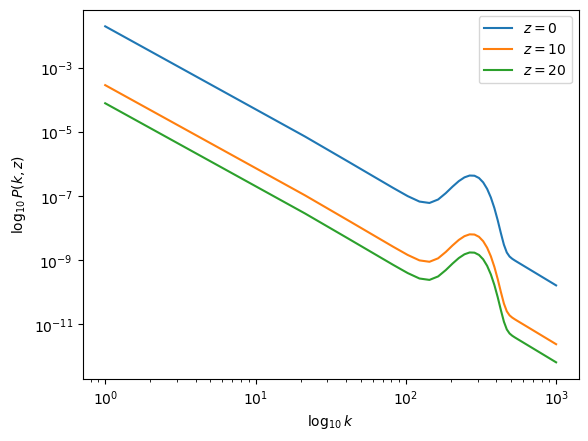

In [245]:
#Const A_G, const z
#plt.loglog(k_range, P_test_vals[0][0], label = r'$k_\mu=30$ Mpc$^{-1}$')
#plt.loglog(k_range, P_test_vals[1][0], label = r'$k_\mu=100$ Mpc$^{-1}$')
plt.loglog(k_range, P_test_vals[2][0], label = r'$k_\mu=300$ Mpc$^{-1}$')

plt.loglog(k_range, P_old_test_vals[0], label = r'$A_\text{G}=0$')

plt.xlabel(r'$\log_{10}k$')
plt.ylabel(r'$\log_{10}P(k,0)$')

plt.legend()
plt.show()

#const A_G, const k_\mu

plt.loglog(k_range, P_test_vals[2][0], label = r'$z=0$')
plt.loglog(k_range, P_test_vals[2][49], label = r'$z=10$')
plt.loglog(k_range, P_test_vals[2][99], label = r'$z=20$')

plt.xlabel(r'$\log_{10}k$')
plt.ylabel(r'$\log_{10}P(k,z)$')

plt.legend()
plt.show()

In [246]:
from utils import M_range, y, y_1, y_10

In [247]:
M_range_new = np.logspace(0, 16, 1000)

In [248]:
#Old powerspectrum sigma for new mass range

y = [A*sigma_M(M,0,np.inf) for M in M_range_new]
y_1 = [A*sigma_M(M,0,1) for M in M_range_new]
y_10 = [A*sigma_M(M,0,10) for M in M_range_new]

In [275]:
y = [A*sigma_M_new(M, 0, 0, k_var_val, z=0, cutoff = np.inf) for M in M_range_new]
y_1 = [A*sigma_M_new(M, 0, 0, k_var_val, z=0, cutoff = np.inf) for M in M_range_new]
y_10 = [A*sigma_M_new(M, 0, 0, k_var_val, z=0, cutoff = np.inf) for M in M_range_new]

In [276]:
y_new = [A_new * sigma_M_new(M, A_G_val, k_mean_val[2], k_var_val, z=0, cutoff = np.inf) for M in M_range_new]
#y_1_new = [A_new * sigma_M_new(M, A_G_val, k_mean_val[2], k_var_val, z=0, cutoff = 1) for M in M_range_new]
#y_10_new = [A_new * sigma_M_new(M, A_G_val, k_mean_val[2], k_var_val, z=0, cutoff = 10) for M in M_range_new]

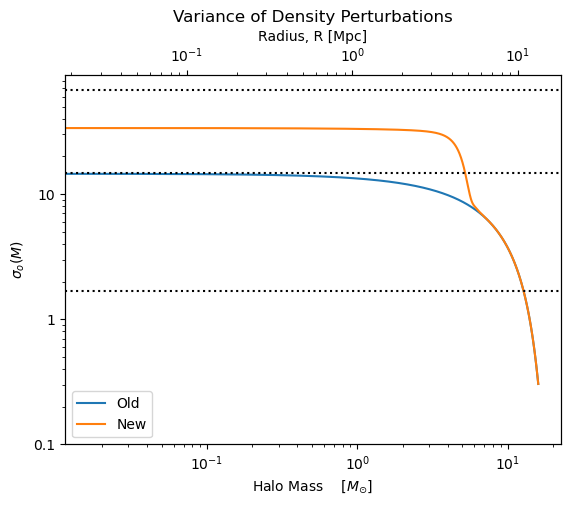

In [293]:
plt.figure()

plt.plot(np.log10(M_range_new), y,label="Old")
#plt.plot(M_range, y_1,label="Cutoff at $k = 1 \ Mpc^{-1}$", ls='--')
#plt.plot(M_range, y_10,label="Cutoff at $k = 10 \ Mpc^{-1}$" , ls='-.')

plt.plot(np.log10(M_range_new), y_new,label="New")

plt.axhline(y=delta_c/D(z=0),ls=':',color='k')
plt.axhline(y=delta_c/D(z=10),ls=':',color='k')
plt.axhline(y=delta_c/D(z=50),ls=':',color='k')

#plt.text(9e14,delta_c/D(z=0)-0.1, "$\delta_c \ (z=0)$", va='top',ha='right',fontsize=13)
#plt.text(9e14,delta_c/D(z=2)-0.2, "$\delta_c \ (z=2)$", va='top',ha='right',fontsize=13)
#plt.text(9e14,delta_c/D(z=5)-0.3, "$\delta_c \ (z=5)$", va='top',ha='right',fontsize=13)

plt.xscale('log')
plt.yscale('log')
#plt.xlim(1e15,1e16)
#plt.ylim(1,2)

plt.xlabel("Halo Mass $\quad [M_{\odot}]$")
plt.ylabel("$\sigma_o(M)$")

plt.yticks([1e-1,1,1e1],["0.1",1,"10"])
plt.legend()

# Duplicate x-axis at the top
ax_top = plt.gca().twiny()                      # Get current axis and create a twin x-axis

ax_top.set_xlim(6,15)                           # Matching bottom axis range
R_range = [(3 * 10**M / (4 * np.pi * rho_0))**(1/3) for M in range(6,16)]
ax_top.set_xticks(R_range)
ax_top.set_xticklabels([f"{R}" for R in R_range])   
ax_top.set_xlabel("Radius, R [Mpc]")
ax_top.set_xscale('log')

# plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.title("Variance of Density Perturbations")

plt.show()

In [292]:
from utils import poly_fit

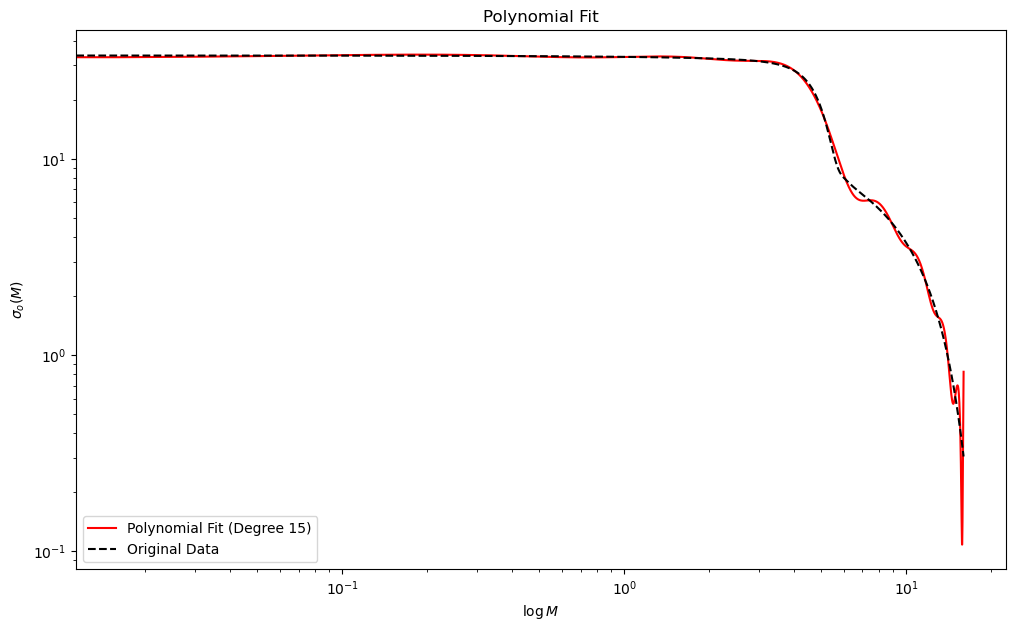

In [286]:
degree = 15
logM_new = np.log10(M_range_new)
sigma_range_new = [A_new*sigma_M_new(M, A_G_val, k_mean_val[2], k_var_val) for M in M_range_new]
cof = poly_fit(logM_new,y_new,degree,plot=True)

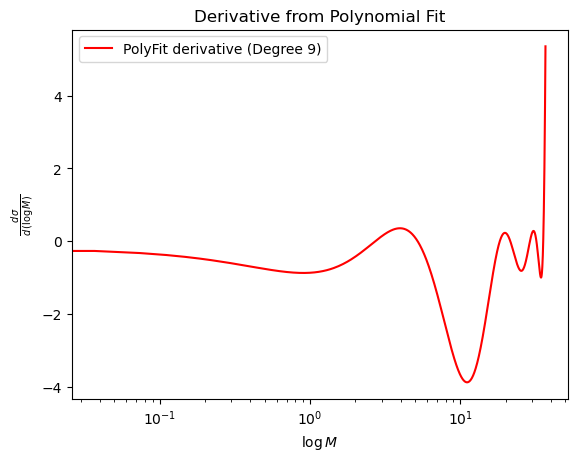

In [280]:
# Evaluating the derivative 

d_cof = np.polyder(cof)

fit_deriv = np.poly1d(d_cof)

# plotting the log-derivative
plt.plot(logM_new, fit_deriv(logM_new), 'r', lw=1.5, label=f'PolyFit derivative (Degree {degree})')
plt.xscale('log')
plt.xlabel(r'$\log M $')
plt.ylabel(r'$ \frac{d\,\sigma}{d\,(\log M)}$')
plt.legend()
plt.title('Derivative from Polynomial Fit')
plt.show()

In [281]:
from utils import PS_MassFunc

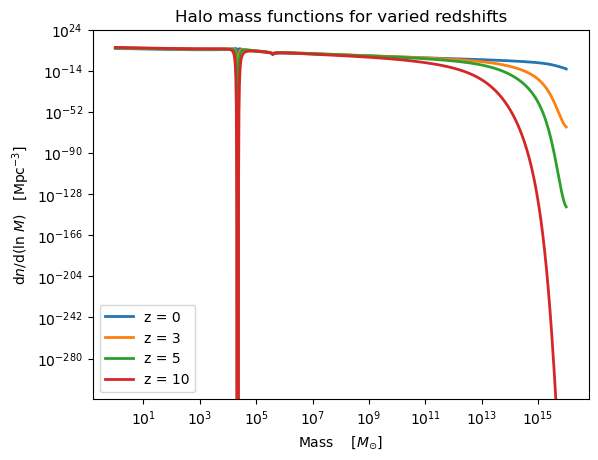

In [282]:
# Plotting abundance of DM halo, n(M,z):
redshifts = [0,3, 5,10]

plt.figure()

for z in redshifts:
    dn_dlogM = [PS_MassFunc(M, z)*(rho_0/M) for M in M_range_new]
    plt.plot(M_range_new, dn_dlogM, lw=2 , label=f"z = {z}")
    
# Plotting mass fraction of halos
plt.xscale('log')
plt.yscale('log')
#plt.xlim(1e6,1e15)
#plt.ylim(1e-8,1e4)

plt.xlabel("Mass $\quad [M_{\odot}]$")
plt.ylabel("d$n/$d$(\ln\,M) \quad $[Mpc$^{-3}$]")
plt.title("Halo mass functions for varied redshifts")

#plt.axvline(2.5 * 10**(10), color = r'firebrick', ls = '--')

plt.legend()
plt.show()